In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_supply_chain_data.csv')

print("="*70)
print("STEP 4: EXPLORATORY DATA ANALYSIS & FEATURE ENGINEERING")
print("="*70)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

STEP 4: EXPLORATORY DATA ANALYSIS & FEATURE ENGINEERING

Dataset Shape: 180,519 rows × 57 columns


In [2]:
print("\n" + "="*70)
print("4.1: SHIPPING MODE ANALYSIS")
print("="*70)

shipping_analysis = df.groupby('Shipping Mode').agg({
    'Order Id': 'count',
    'Delay_Days': ['mean', 'median', 'std'],
    'Is_Late': 'mean',
    'Sales per customer': 'mean'
}).round(2)

shipping_analysis.columns = ['Order_Count', 'Avg_Delay', 'Median_Delay', 'Std_Delay', 'Late_Rate', 'Avg_Sales']

print("\nShipping Mode Performance:")
print(shipping_analysis)


4.1: SHIPPING MODE ANALYSIS

Shipping Mode Performance:
                Order_Count  Avg_Delay  Median_Delay  Std_Delay  Late_Rate  \
Shipping Mode                                                                
First Class           27814       1.00           1.0       0.00       1.00   
Same Day               9737       0.48           0.0       0.50       0.48   
Second Class          35216       1.99           2.0       1.42       0.80   
Standard Class       107752      -0.00           0.0       1.42       0.40   

                Avg_Sales  
Shipping Mode              
First Class        183.38  
Same Day           179.23  
Second Class       182.20  
Standard Class     183.68  


In [3]:
print("\n" + "="*70)
print("4.2: REGIONAL ANALYSIS (Top States)")
print("="*70)

regional_analysis = df.groupby('Customer State').agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean',
}).round(2)

regional_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate']
regional_analysis = regional_analysis.sort_values('Order_Count', ascending=False).head(10)

print("\nTop 10 States by Order Volume:")
print(regional_analysis)


4.2: REGIONAL ANALYSIS (Top States)

Top 10 States by Order Volume:
                Order_Count  Avg_Delay  Late_Rate
Customer State                                   
PR                    69373       0.56       0.57
CA                    29223       0.57       0.58
NY                    11327       0.50       0.56
TX                     9103       0.57       0.58
IL                     7631       0.61       0.58
FL                     5456       0.58       0.57
OH                     4095       0.62       0.58
PA                     3824       0.55       0.56
MI                     3804       0.56       0.56
NJ                     3191       0.50       0.55


In [5]:
print("\n" + "="*70)
print("4.3: PRODUCT CATEGORY ANALYSIS (Top Categories)")
print("="*70)

category_analysis = df.groupby('Category Name').agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean',
    'Sales per customer': 'mean'
}).round(2)

category_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate', 'Avg_Sales']
category_analysis = category_analysis.sort_values('Order_Count', ascending=False).head(10)

print("\nTop 10 Categories by Order Volume:")
print(category_analysis)


4.3: PRODUCT CATEGORY ANALYSIS (Top Categories)

Top 10 Categories by Order Volume:
                      Order_Count  Avg_Delay  Late_Rate  Avg_Sales
Category Name                                                     
Cleats                      24551       0.58       0.57     162.23
Men's Footwear              22246       0.56       0.57     116.81
Women's Apparel             21035       0.56       0.57     134.48
Indoor/Outdoor Games        19298       0.56       0.57     134.55
Fishing                     17325       0.56       0.57     359.42
Water Sports                15540       0.57       0.57     180.05
Camping & Hiking            13729       0.55       0.57     269.56
Cardio Equipment            12487       0.55       0.57     265.90
Shop By Sport               10984       0.58       0.58     107.17
Electronics                  3156       0.57       0.59     105.62


In [6]:
print("\n" + "="*70)
print("4.4: CUSTOMER SEGMENT ANALYSIS")
print("="*70)

segment_analysis = df.groupby('Customer Segment').agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean',
    'Sales per customer': 'mean'
}).round(2)

segment_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate', 'Avg_Sales']

print("\nCustomer Segment Performance:")
print(segment_analysis)


4.4: CUSTOMER SEGMENT ANALYSIS

Customer Segment Performance:
                  Order_Count  Avg_Delay  Late_Rate  Avg_Sales
Customer Segment                                              
Consumer                93504       0.56       0.57     183.57
Corporate               54789       0.56       0.57     183.08
Home Office             32226       0.58       0.58     181.82


In [7]:
print("\n" + "="*70)
print("4.5: DISTANCE & COORDINATES ANALYSIS")
print("="*70)

print(f"\nLatitude range: {df['Latitude'].min():.2f} to {df['Latitude'].max():.2f}")
print(f"Longitude range: {df['Longitude'].min():.2f} to {df['Longitude'].max():.2f}")

# Create distance buckets (simplified - using product of lat*long as proxy)
df['Distance_Proxy'] = np.sqrt(df['Latitude']**2 + df['Longitude']**2)
df['Distance_Bucket'] = pd.cut(df['Distance_Proxy'], bins=4, labels=['Very Close', 'Close', 'Far', 'Very Far'])

distance_analysis = df.groupby('Distance_Bucket').agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean'
}).round(2)

distance_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate']

print("\nDistance Bucket Analysis:")
print(distance_analysis)


4.5: DISTANCE & COORDINATES ANALYSIS

Latitude range: -33.94 to 48.78
Longitude range: -158.03 to 115.26

Distance Bucket Analysis:
                 Order_Count  Avg_Delay  Late_Rate
Distance_Bucket                                   
Very Close             67610       0.56       0.57
Close                  58220       0.57       0.57
Far                    51289       0.57       0.57
Very Far                3400       0.54       0.58


C:\Users\Admin\AppData\Local\Temp\ipykernel_7812\2673175456.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_analysis = df.groupby('Distance_Bucket').agg({


In [8]:
print("\n" + "="*70)
print("4.6: SALES & REVENUE ANALYSIS")
print("="*70)

# Create sales buckets
df['Sales_Bucket'] = pd.cut(df['Sales per customer'], 
                             bins=[0, 500, 1000, 2000, 10000],
                             labels=['Low (<500)', 'Medium (500-1000)', 'High (1000-2000)', 'Very High (2000+)'])

sales_analysis = df.groupby('Sales_Bucket').agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean'
}).round(2)

sales_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate']

print("\nSales Bucket Analysis:")
print(sales_analysis)


4.6: SALES & REVENUE ANALYSIS

Sales Bucket Analysis:
                   Order_Count  Avg_Delay  Late_Rate
Sales_Bucket                                        
Low (<500)              179848       0.57       0.57
Medium (500-1000)          214       0.57       0.56
High (1000-2000)           457       0.45       0.52
Very High (2000+)            0        NaN        NaN


C:\Users\Admin\AppData\Local\Temp\ipykernel_7812\377825608.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_analysis = df.groupby('Sales_Bucket').agg({


In [9]:
print("\n" + "="*70)
print("4.7: TIME-BASED ANALYSIS")
print("="*70)

df['Order_YearMonth'] = pd.to_datetime(df['Shipping date (DateOrders)']).dt.to_period('M')

time_analysis = df.groupby(df['Order_YearMonth'].astype(str)).agg({
    'Order Id': 'count',
    'Delay_Days': 'mean',
    'Is_Late': 'mean'
}).round(2)

time_analysis.columns = ['Order_Count', 'Avg_Delay', 'Late_Rate']

print("\nMonthly Trend (First 12 months):")
print(time_analysis.head(12))


4.7: TIME-BASED ANALYSIS

Monthly Trend (First 12 months):
                 Order_Count  Avg_Delay  Late_Rate
Order_YearMonth                                   
2015-01                 4697       0.48       0.54
2015-02                 4783       0.59       0.57
2015-03                 5313       0.59       0.58
2015-04                 5134       0.54       0.56
2015-05                 5297       0.56       0.58
2015-06                 5161       0.55       0.57
2015-07                 5361       0.56       0.57
2015-08                 5236       0.57       0.57
2015-09                 5197       0.59       0.59
2015-10                 5234       0.57       0.58
2015-11                 5238       0.55       0.56
2015-12                 5351       0.56       0.57



4.8: CREATING VISUALIZATIONS
✓ Saved: eda_visualizations_1.png


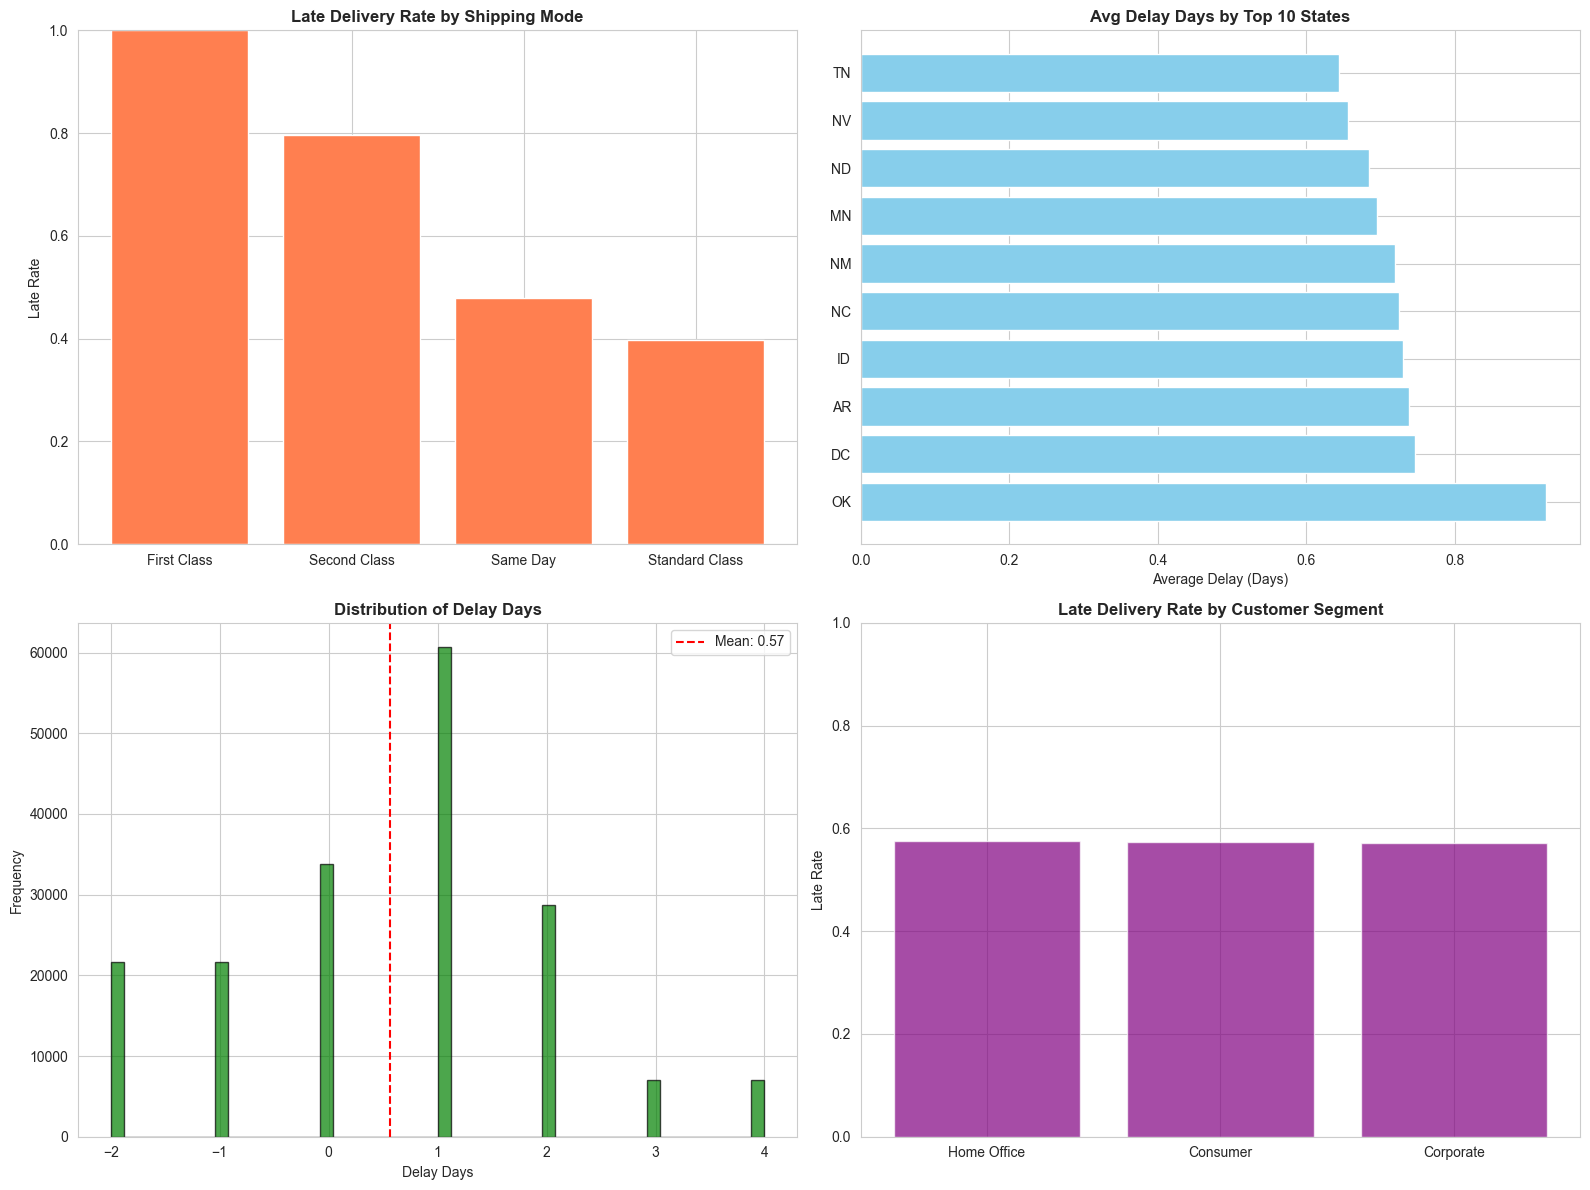

In [10]:
print("\n" + "="*70)
print("4.8: CREATING VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Late Rate by Shipping Mode
shipping_mode_late = df.groupby('Shipping Mode')['Is_Late'].mean().sort_values(ascending=False)
axes[0, 0].bar(shipping_mode_late.index, shipping_mode_late.values, color='coral')
axes[0, 0].set_title('Late Delivery Rate by Shipping Mode', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Late Rate')
axes[0, 0].set_ylim(0, 1)

# Plot 2: Avg Delay by Top States
top_states = df.groupby('Customer State')['Delay_Days'].mean().sort_values(ascending=False).head(10)
axes[0, 1].barh(top_states.index, top_states.values, color='skyblue')
axes[0, 1].set_title('Avg Delay Days by Top 10 States', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Delay (Days)')

# Plot 3: Delay Distribution Histogram
axes[1, 0].hist(df['Delay_Days'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Delay Days', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Delay Days')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['Delay_Days'].mean(), color='red', linestyle='--', label=f"Mean: {df['Delay_Days'].mean():.2f}")
axes[1, 0].legend()

# Plot 4: Late Rate by Customer Segment
segment_late = df.groupby('Customer Segment')['Is_Late'].mean().sort_values(ascending=False)
axes[1, 1].bar(segment_late.index, segment_late.values, color='purple', alpha=0.7)
axes[1, 1].set_title('Late Delivery Rate by Customer Segment', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Late Rate')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/processed/eda_visualizations_1.png', dpi=300, bbox_inches='tight')
print("✓ Saved: eda_visualizations_1.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_7812\3693817041.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_late = df.groupby('Sales_Bucket')['Is_Late'].mean()


✓ Saved: eda_visualizations_2.png


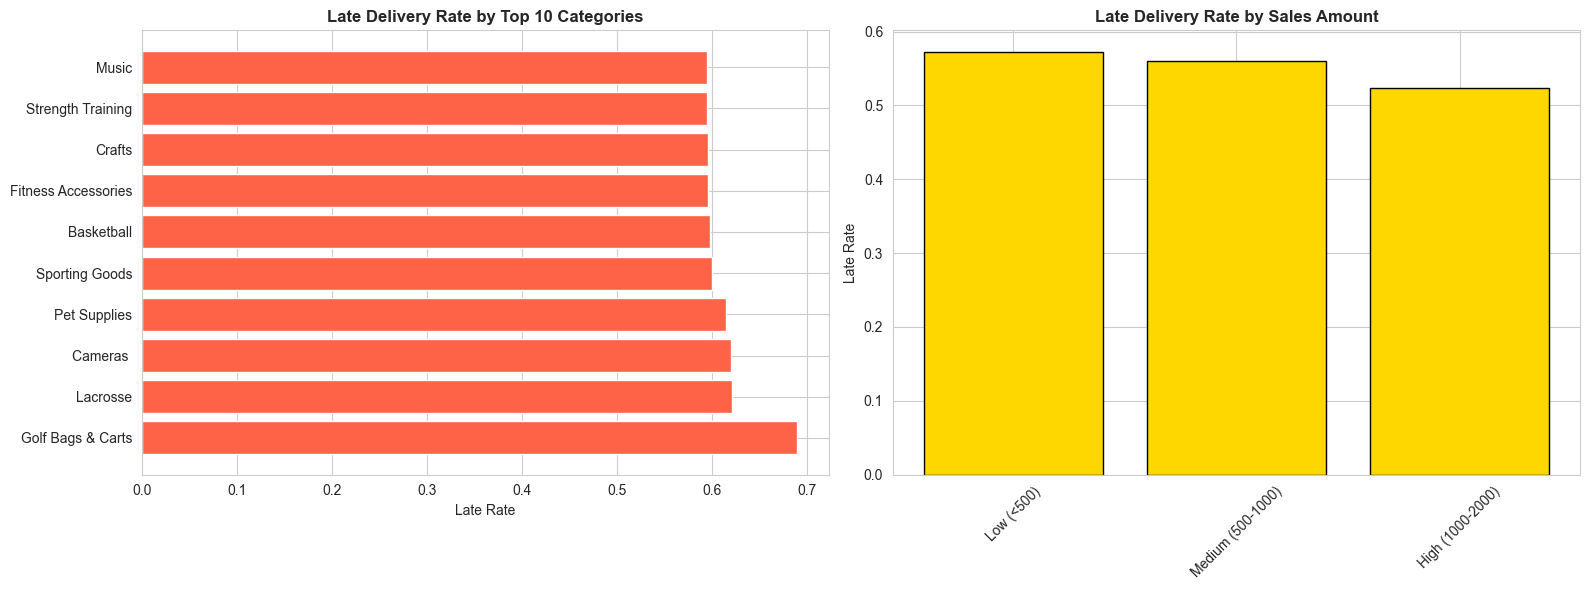

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top Categories by Late Rate
top_categories_late = df.groupby('Category Name')['Is_Late'].mean().sort_values(ascending=False).head(10)
axes[0].barh(top_categories_late.index, top_categories_late.values, color='tomato')
axes[0].set_title('Late Delivery Rate by Top 10 Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Late Rate')

# Plot 2: Sales Bucket vs Late Rate
sales_late = df.groupby('Sales_Bucket')['Is_Late'].mean()
axes[1].bar(sales_late.index, sales_late.values, color='gold', edgecolor='black')
axes[1].set_title('Late Delivery Rate by Sales Amount', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Late Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/eda_visualizations_2.png', dpi=300, bbox_inches='tight')
print("✓ Saved: eda_visualizations_2.png")
plt.show()

✓ Saved: eda_visualizations_3.png


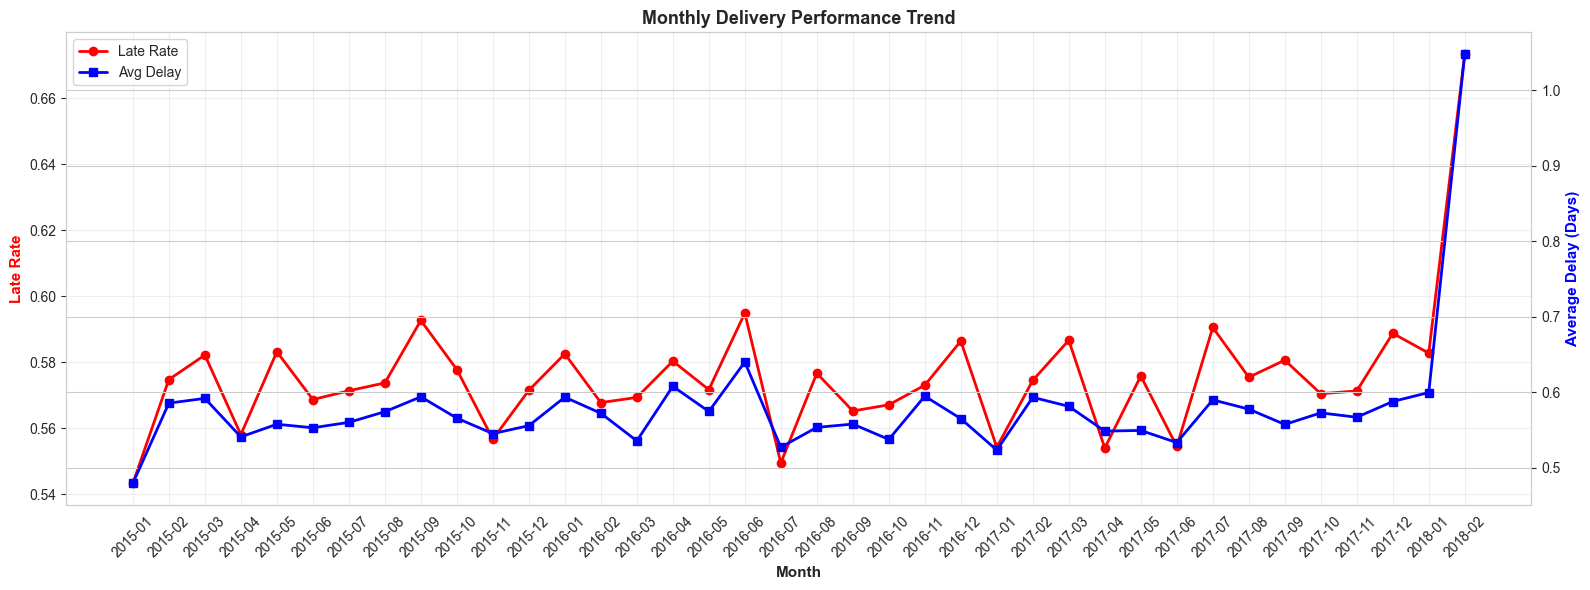

In [12]:
fig, ax = plt.subplots(figsize=(16, 6))

# Monthly trend
monthly_trend = df.groupby(df['Order_YearMonth'].astype(str)).agg({
    'Is_Late': 'mean',
    'Delay_Days': 'mean'
})

ax2 = ax.twinx()

line1 = ax.plot(monthly_trend.index, monthly_trend['Is_Late'], marker='o', color='red', linewidth=2, label='Late Rate')
line2 = ax2.plot(monthly_trend.index, monthly_trend['Delay_Days'], marker='s', color='blue', linewidth=2, label='Avg Delay')

ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Late Rate', color='red', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Delay (Days)', color='blue', fontsize=11, fontweight='bold')
ax.set_title('Monthly Delivery Performance Trend', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('../data/processed/eda_visualizations_3.png', dpi=300, bbox_inches='tight')
print("✓ Saved: eda_visualizations_3.png")
plt.show()


4.9: CORRELATION ANALYSIS

Top Correlations with Delay_Days:
Delay_Days                       1.000000
Is_Late                          0.816184
Days for shipping (real)         0.613475
Longitude                        0.000871
Distance_Proxy                   0.000510
Latitude                         0.000450
Sales per customer              -0.004028
Benefit per order               -0.005385
Days for shipment (scheduled)   -0.360037
Name: Delay_Days, dtype: float64

✓ Saved: correlation_matrix.png


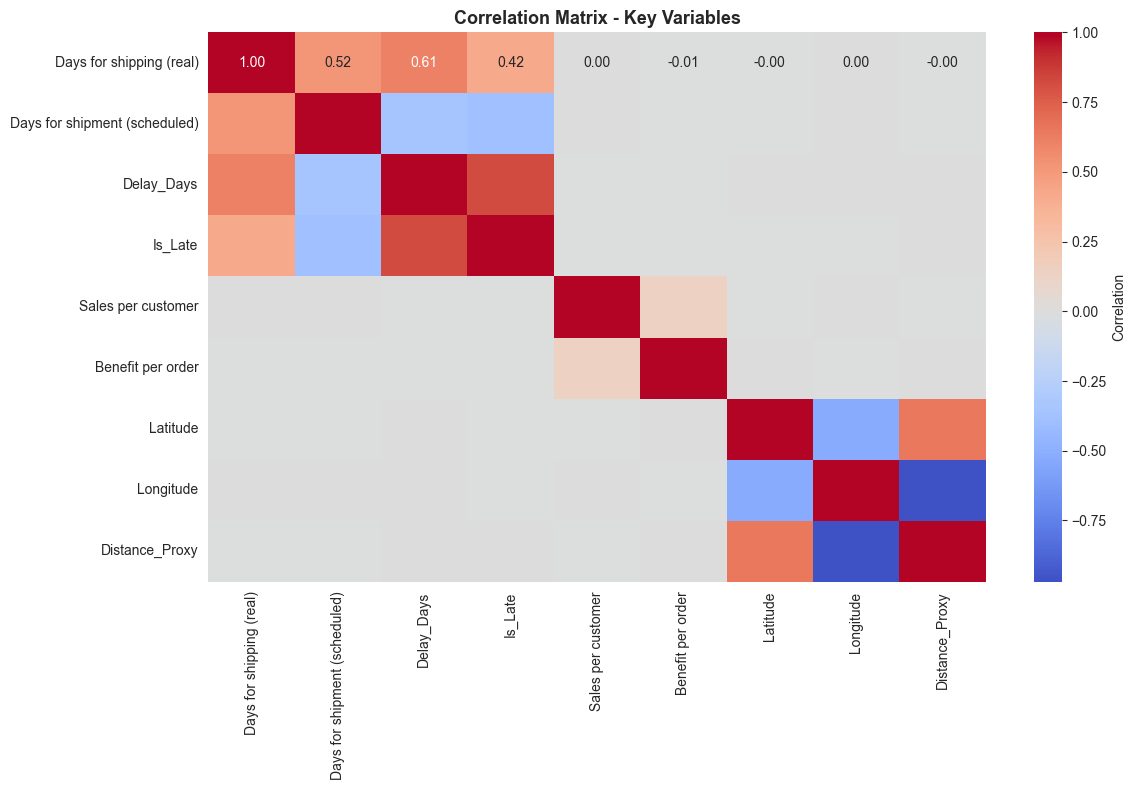

In [13]:
print("\n" + "="*70)
print("4.9: CORRELATION ANALYSIS")
print("="*70)

# Select numeric columns for correlation
numeric_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 
                'Delay_Days', 'Is_Late', 'Sales per customer', 'Benefit per order',
                'Latitude', 'Longitude', 'Distance_Proxy']

correlation_matrix = df[numeric_cols].corr()

print("\nTop Correlations with Delay_Days:")
print(correlation_matrix['Delay_Days'].sort_values(ascending=False).head(10))

# Visualize correlation
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Key Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: correlation_matrix.png")
plt.show()

In [14]:
print("\n" + "="*70)
print("4.10: SAVING ENHANCED DATA")
print("="*70)

df.to_csv('../data/processed/master_delivery_data.csv', index=False)
print(f"✓ Enhanced dataset saved: master_delivery_data.csv")
print(f"  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNew features created:")
print(f"  - Distance_Proxy")
print(f"  - Distance_Bucket")
print(f"  - Sales_Bucket")
print(f"  - Order_YearMonth")


4.10: SAVING ENHANCED DATA
✓ Enhanced dataset saved: master_delivery_data.csv
  Final shape: 180,519 rows × 60 columns

New features created:
  - Distance_Proxy
  - Distance_Bucket
  - Sales_Bucket
  - Order_YearMonth


In [16]:
print("\n" + "="*70)
print("4.11: KEY INSIGHTS FROM EDA")
print("="*70)

print(f"\n1. OVERALL DELIVERY PERFORMANCE:")
print(f"   - Late delivery rate: {df['Is_Late'].mean()*100:.1f}%")
print(f"   - Average delay: {df['Delay_Days'].mean():.2f} days")
print(f"   - Median delay: {df['Delay_Days'].median():.2f} days")
print(f"   - Max delay: {df['Delay_Days'].max():.0f} days")

print(f"\n2. SHIPPING MODE INSIGHTS:")
worst_shipping = shipping_analysis['Late_Rate'].idxmax()
print(f"   - Worst performer: {worst_shipping} ({shipping_analysis.loc[worst_shipping, 'Late_Rate']*100:.1f}% late)")
print(f"   - Order count: {shipping_analysis.loc[worst_shipping, 'Order_Count']:.0f}")

print(f"\n3. REGIONAL INSIGHTS:")
worst_state = regional_analysis['Late_Rate'].idxmax()
print(f"   - Worst state: {worst_state} ({regional_analysis.loc[worst_state, 'Late_Rate']*100:.1f}% late)")
print(f"   - Order count: {regional_analysis.loc[worst_state, 'Order_Count']:.0f}")

print(f"\n4. CATEGORY INSIGHTS:")
worst_category = category_analysis['Late_Rate'].idxmax()
print(f"   - Worst category: {worst_category} ({category_analysis.loc[worst_category, 'Late_Rate']*100:.1f}% late)")
print(f"   - Order count: {category_analysis.loc[worst_category, 'Order_Count']:.0f}")

print(f"\n5. CUSTOMER SEGMENT INSIGHTS:")
worst_segment = segment_analysis['Late_Rate'].idxmax()
print(f"   - Worst segment: {worst_segment} ({segment_analysis.loc[worst_segment, 'Late_Rate']*100:.1f}% late)")



4.11: KEY INSIGHTS FROM EDA

1. OVERALL DELIVERY PERFORMANCE:
   - Late delivery rate: 57.3%
   - Average delay: 0.57 days
   - Median delay: 1.00 days
   - Max delay: 4 days

2. SHIPPING MODE INSIGHTS:
   - Worst performer: First Class (100.0% late)
   - Order count: 27814

3. REGIONAL INSIGHTS:
   - Worst state: CA (58.0% late)
   - Order count: 29223

4. CATEGORY INSIGHTS:
   - Worst category: Electronics (59.0% late)
   - Order count: 3156

5. CUSTOMER SEGMENT INSIGHTS:
   - Worst segment: Home Office (58.0% late)
